Name - Kuvam Sharma

Student ID - iitp_aiml_2506443

# Importing the tuned models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import joblib

logistic_regression = joblib.load("/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Models/logistic_regression.pkl")
random_forest = joblib.load("/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Models/random_forest.pkl")
decision_tree = joblib.load("/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Models/decision_tree.pkl")
xgboost = joblib.load("/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Models/xgboost.pkl")
metrics_dict = joblib.load(
    "/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Evaluation_Metrics/all_model_metrics.pkl"
)
X_test = joblib.load("/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Data/X_test.pkl")
y_test = joblib.load("/content/drive/MyDrive/T2_Project_Kuvam_Sharma_iitp_aiml_2506443/Data/y_test.pkl")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from IPython.display import display, Markdown


In [ ]:
metrics = {"XGBoost": {
    'Accuracy':  metrics_dict["XGBoost"]["accuracy"],
    'Precision_Class_0': metrics_dict["XGBoost"]["precision_class0"],
    'Precision_Class_1': metrics_dict["XGBoost"]["precision_class1"],
    'Recall_Class_0': metrics_dict["XGBoost"]["recall_class0"],
    'Recall_Class_1': metrics_dict["XGBoost"]["recall_class1"],
    'F1-Score_Class_0': metrics_dict["XGBoost"]["f1_class0"],
    'F1-Score_Class_1': metrics_dict["XGBoost"]["f1_class1"],
    'AUC-ROC': metrics_dict["XGBoost"]["roc_auc"]},

    "RandomForest": {
    'Accuracy':  metrics_dict["RandomForest"]["accuracy"],
    'Precision_Class_0': metrics_dict["RandomForest"]["precision_class0"],
    'Precision_Class_1': metrics_dict["RandomForest"]["precision_class1"],
    'Recall_Class_0': metrics_dict["RandomForest"]["recall_class0"],
    'Recall_Class_1': metrics_dict["RandomForest"]["recall_class1"],
    'F1-Score_Class_0': metrics_dict["RandomForest"]["f1_class0"],
    'F1-Score_Class_1': metrics_dict["RandomForest"]["f1_class1"],
    'AUC-ROC': metrics_dict["RandomForest"]["roc_auc"]},

    "DecisionTree": {
    'Accuracy':  metrics_dict["DecisionTree"]["accuracy"],
    'Precision_Class_0': metrics_dict["DecisionTree"]["precision_class0"],
    'Precision_Class_1': metrics_dict["DecisionTree"]["precision_class1"],
    'Recall_Class_0': metrics_dict["DecisionTree"]["recall_class0"],
    'Recall_Class_1': metrics_dict["DecisionTree"]["recall_class1"],
    'F1-Score_Class_0': metrics_dict["DecisionTree"]["f1_class0"],
    'F1-Score_Class_1': metrics_dict["DecisionTree"]["f1_class1"],
    'AUC-ROC': metrics_dict["DecisionTree"]["roc_auc"]},

    "LogisticRegression": {
    'Accuracy':  metrics_dict["LogisticRegression"]["accuracy"],
    'Precision_Class_0': metrics_dict["LogisticRegression"]["precision_class0"],
    'Precision_Class_1': metrics_dict["LogisticRegression"]["precision_class1"],
    'Recall_Class_0': metrics_dict["LogisticRegression"]["recall_class0"],
    'Recall_Class_1': metrics_dict["LogisticRegression"]["recall_class1"],
    'F1-Score_Class_0': metrics_dict["LogisticRegression"]["f1_class0"],
    'F1-Score_Class_1': metrics_dict["LogisticRegression"]["f1_class1"],
    'AUC-ROC': metrics_dict["LogisticRegression"]["roc_auc"]}}

# Model Evaluation & Visualisation

In [ ]:
summary = pd.DataFrame(metrics).T
summary = summary.astype(float).round(4)
summary

,Accuracy,Precision_Class_0,Precision_Class_1,Recall_Class_0,Recall_Class_1,F1-Score_Class_0,F1-Score_Class_1,AUC-ROC
XGBoost,0.875,0.8871,0.8553,0.9091,0.8228,0.8980,0.8387,0.9408
RandomForest,0.850,0.8527,0.8451,0.9091,0.7595,0.8800,0.8000,0.9250
DecisionTree,0.820,0.8761,0.7471,0.8182,0.8228,0.8462,0.7831,0.8691
LogisticRegression,0.775,0.7969,0.7361,0.8430,0.6709,0.8193,0.7020,0.8402


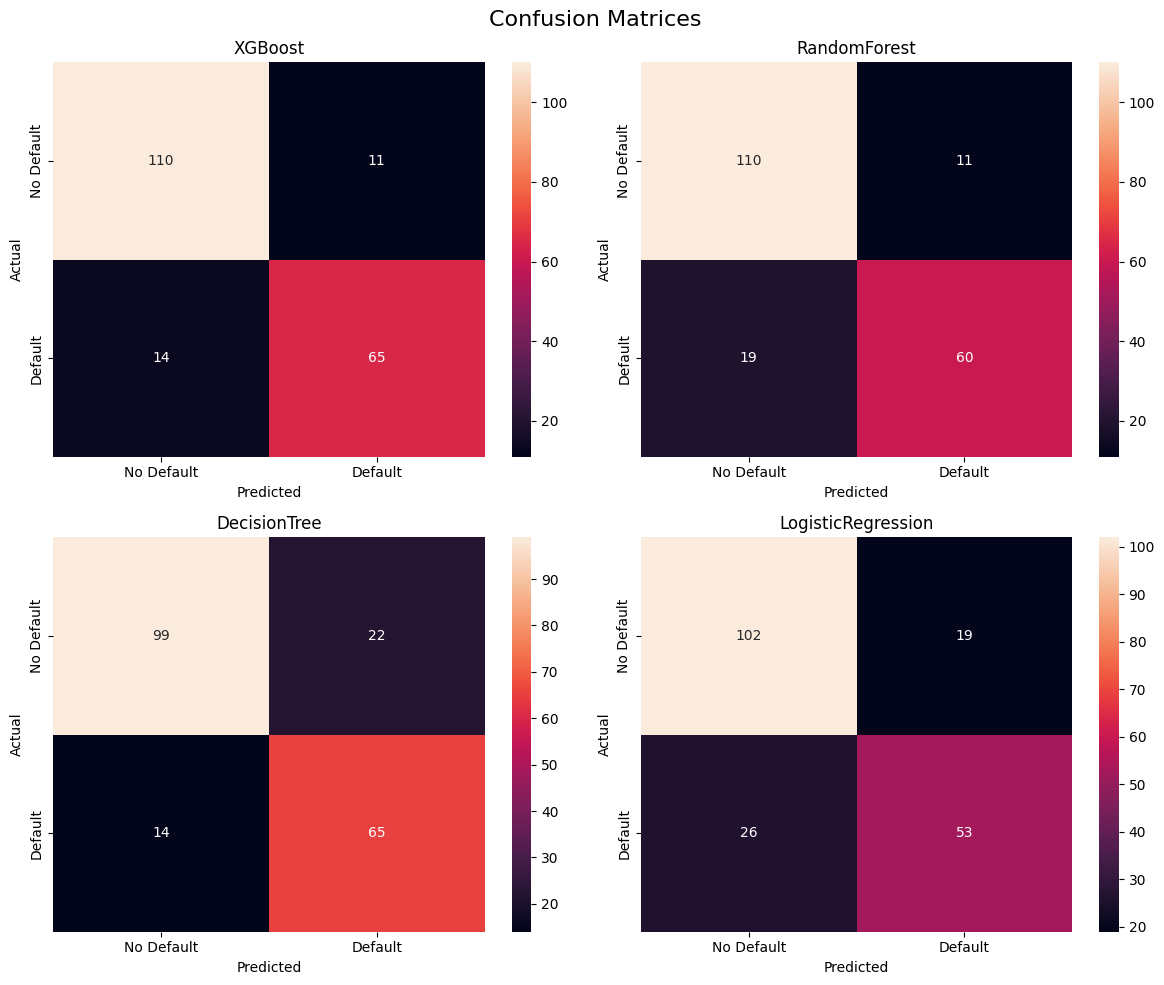

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Confusion Matrices", fontsize=16)

y_pred_xgb = xgboost.predict(X_test)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', ax=axes[0][0],
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
axes[0][0].set_title("XGBoost")
axes[0][0].set_xlabel("Predicted")
axes[0][0].set_ylabel("Actual")

y_pred_rf = random_forest.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[0][1],
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
axes[0][1].set_title("RandomForest")
axes[0][1].set_xlabel("Predicted")
axes[0][1].set_ylabel("Actual")

y_pred_dt = decision_tree.predict(X_test)
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', ax=axes[1][0],
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
axes[1][0].set_title("DecisionTree")
axes[1][0].set_xlabel("Predicted")
axes[1][0].set_ylabel("Actual")

y_pred_lr = logistic_regression.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[1][1],
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
axes[1][1].set_title("LogisticRegression")
axes[1][1].set_xlabel("Predicted")
axes[1][1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png")
plt.show()

<h2>Confusion Matrix Interepretation

The confusion matrices provide a detailed breakdown of True Positives, True Negatives, False Positives and False Negatives for each model.

. The top left cell represents correctly predicted non-defaulters (True Negatives).

. The bottom right cell represents correctly predicted defaulters (True Positives).

. The off diagnol cells represent misclassifications (False Negatives & False Positives).

### Comparing the models:

. XGBoost and Random Forest show stronger balance between correctly identifying defaulters and minimising false alarms.

. Decision Tree shows slightly higher misclassification.

. Logistic Regression is more conservative but still competitive.

From a business perspective, minimizing False Negatives (missed defaulters) is particularly important, as they result in direct financial loss.

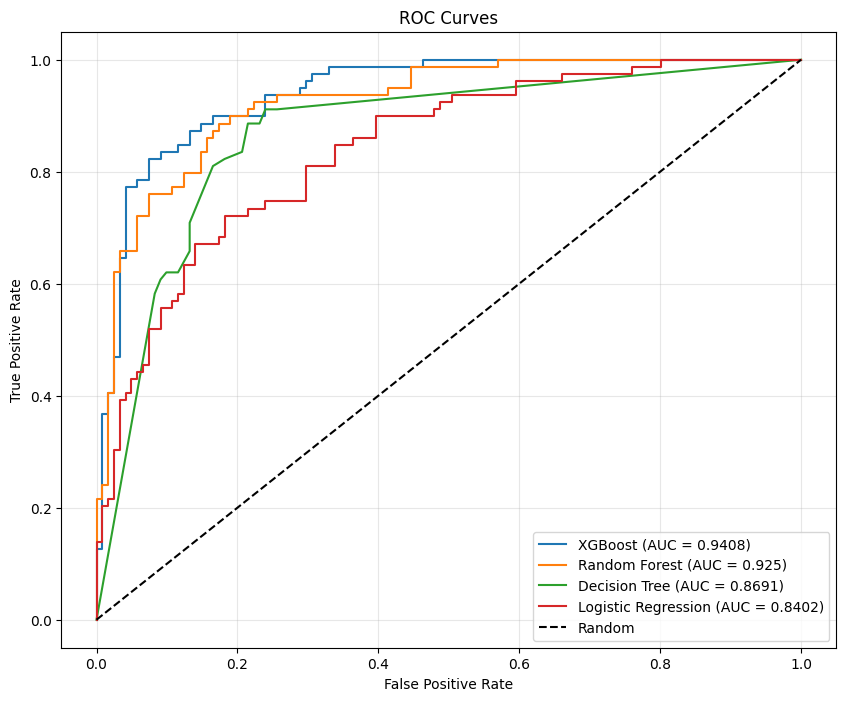

In [ ]:
plt.figure(figsize=(10,8))

xgb_probs = xgboost.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label = "XGBoost (AUC = " + str(round(auc_xgb, 4)) + ")")

rf_probs = random_forest.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label = "Random Forest (AUC = " + str(round(auc_rf, 4)) + ")")

dt_probs = decision_tree.predict_proba(X_test)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label = "Decision Tree (AUC = " + str(round(auc_dt, 4)) + ")")

lr_probs = logistic_regression.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label = "Logistic Regression (AUC = " + str(round(auc_lr, 4)) + ")")

plt.plot([0,1], [0,1], "k--", label = "Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(alpha = 0.3)
plt.savefig("roc_curves.png")
plt.show()

<h2> ROC Curve Analysis

The ROC curve illustrates the trade-off between True Positive Rate (Recall) and False Positive Rate across different classification thresholds.

. A curve closer to the top-left corner indicates better discrimination ability.

. The diagonal dashed line represents random guessing (AUC = 0.5)

XGBoost achieves the highest AUC, followed by Random Forest, indicating strong class seperation capability.

Logistic Regression performs resonably well but is slightly weaker in capturing non linear relationships.

SInce ROC-AUC evaluates performance across all thresholds, it confirms that tree-based models are better at distinguishing between defaulters and non-defaulters.

# Feature Importance

In [ ]:
xgb_importances = xgboost.named_steps["classifier"].feature_importances_
rf_importances = random_forest.named_steps["classifier"].feature_importances_
dt_importances = decision_tree.named_steps["classifier"].feature_importances_

In [ ]:
feature_names = X_test.columns

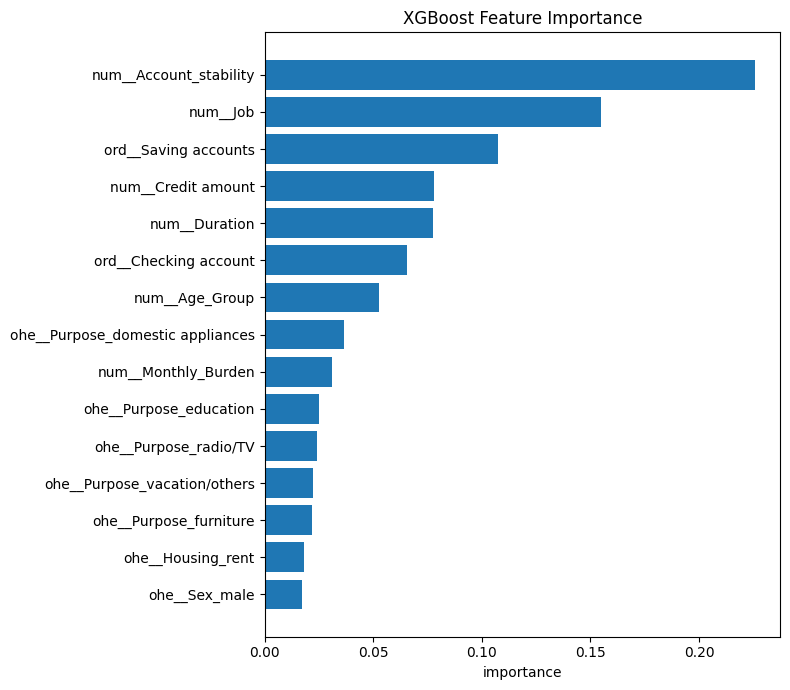

In [ ]:
xgb_feat_df = pd.DataFrame()
xgb_feat_df['Feature'] = feature_names
xgb_feat_df['Importance'] = xgb_importances
xgb_feat_df = xgb_feat_df.sort_values('Importance').tail(15)

plt.figure(figsize = (8,7))
plt.barh(xgb_feat_df['Feature'], xgb_feat_df['Importance'])
plt.title("XGBoost Feature Importance")
plt.xlabel("importance")
plt.tight_layout()
plt.savefig('importance_xgb.png')
plt.show()

<h2>XGBoost Feature Importance

The feature importance plot highlights the variables that contribute most to model decisions.

The most influential features include:
. "Account Stability"
. "Job Category"
. "Saving Accounts"
. "Credit Amount"

This indicates that financial stability and borrowing behaviour are strong predictors of credit risk.

These insights align with real-world credit scoring logic, improving the model's business interepretability.

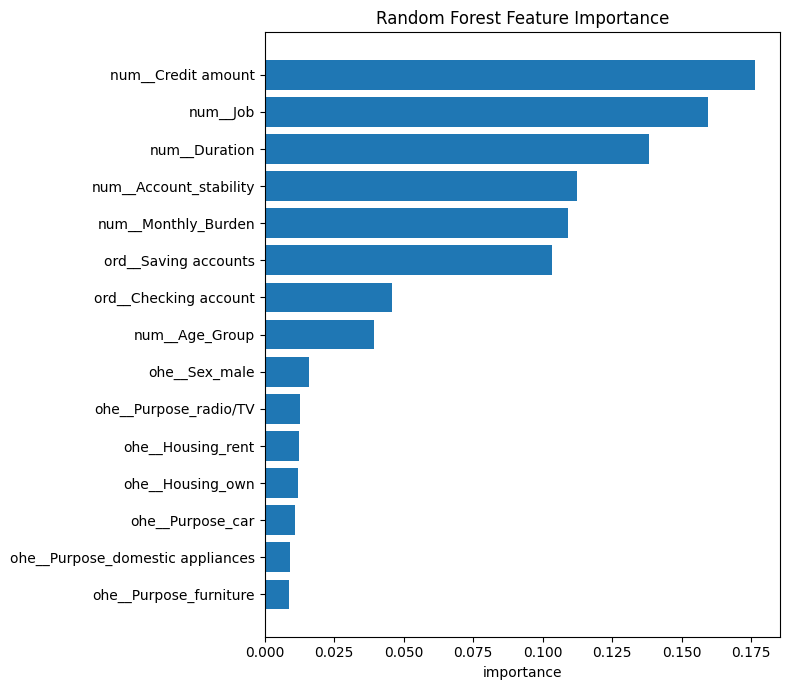

In [ ]:
rf_feat_df = pd.DataFrame()
rf_feat_df['Feature'] = feature_names
rf_feat_df['Importance'] = rf_importances
rf_feat_df = rf_feat_df.sort_values('Importance').tail(15)

plt.figure(figsize = (8,7))
plt.barh(rf_feat_df['Feature'], rf_feat_df['Importance'])
plt.title("Random Forest Feature Importance")
plt.xlabel("importance")
plt.tight_layout()
plt.savefig('importance_rf.png')
plt.show()

<h2> Random Forest Feature Importance Cell

Random Forest identifies credit amount, job, and loan duration as key predictors.

Compared to XGBoost, Random Forest distributes importance more evenly across features, reflecting its averaging mechanism across multiple trees.

The importance of credit amount and duration suggests that larger and longer loans carry higher default risk.

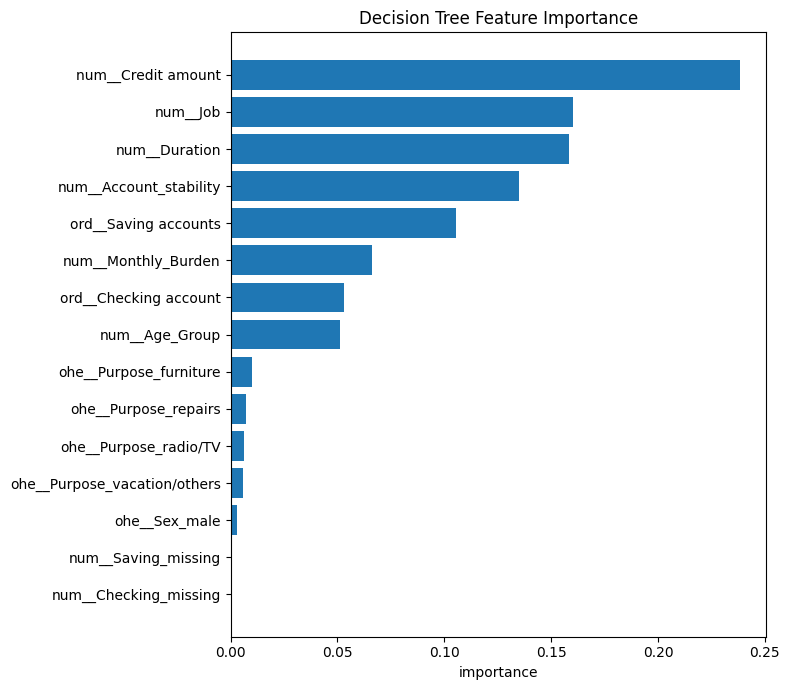

In [ ]:
dt_feat_df = pd.DataFrame()
dt_feat_df['Feature'] = feature_names
dt_feat_df['Importance'] = dt_importances
dt_feat_df = dt_feat_df.sort_values('Importance').tail(15)

plt.figure(figsize = (8,7))
plt.barh(dt_feat_df['Feature'], dt_feat_df['Importance'])
plt.title("Decision Tree Feature Importance")
plt.xlabel("importance")
plt.tight_layout()
plt.savefig('importance_dt.png')
plt.show()

<h2> Decision Tree Feature Importance Cell

The Decision Tree model heavily relies on a smaller subset of features, particularly credit amount and job.

Unlike ensemble models, single trees may overemphasize specific splits, which can lead to overfitting.

While easier to interpret, the model’s performance indicates reduced generalization compared to ensemble methods.

In [ ]:
recall_scores = {
    "XGBoost":            summary.loc["XGBoost", "Recall_Class_1"],
    "RandomForest":       summary.loc["RandomForest", "Recall_Class_1"],
    "DecisionTree":       summary.loc["DecisionTree", "Recall_Class_1"],
    "LogisticRegression": summary.loc["LogisticRegression", "Recall_Class_1"]
}

In [ ]:
best_model_name = max(recall_scores, key=recall_scores.get)
print("best model is: ", best_model_name)

best model is:  XGBoost


In [ ]:
if best_model_name == "XGBoost":
    best_pipeline = xgboost
elif best_model_name == "RandomForest":
    best_pipeline = random_forest
elif best_model_name == "DecisionTree":
    best_pipeline = decision_tree
else:
    best_pipeline = logistic_regression

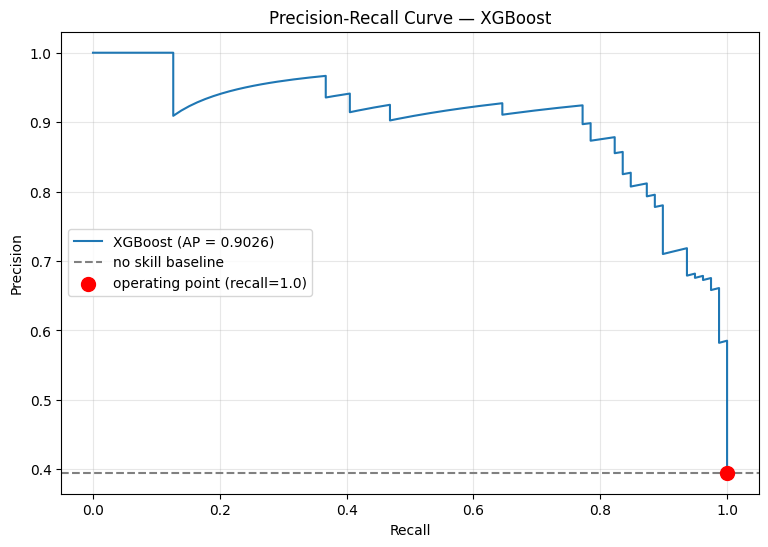

In [ ]:
best_probs = best_pipeline.predict_proba(X_test)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, best_probs)
ap = average_precision_score(y_test, best_probs)

plt.figure(figsize=(9, 6))
plt.plot(rec, prec, label=best_model_name + " (AP = " + str(round(ap, 4)) + ")")

no_skill = y_test.mean()
plt.axhline(no_skill, color="grey", linestyle="--", label="no skill baseline")

op_recall = None
op_prec   = None
op_thresh = None

for i in range(len(rec)):
    if rec[i] >= 0.75:
        op_recall = rec[i]
        op_prec   = prec[i]
        op_thresh = thresholds[i]
        break

if op_recall is not None:
    plt.scatter(op_recall, op_prec, color="red", s=100, zorder=5,
                label="operating point (recall=" + str(round(op_recall, 2)) + ")")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — " + best_model_name)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("pr_curve.png")
plt.show()

<h2> Precision-Recall Curve Analysis

The Precision-Recall curve focuses specifically on performance for the positive class (defaulters).

This metric is especially important in imbalanced classification problems, where correctly identifying defaulters is critical.

The curve demonstrates that the selected model maintains strong precision even at higher recall levels.

The Average Precision (AP) score further confirms robust detection capability.

For deployment, adjusting the classification threshold can further increase recall if the business prioritizes risk minimization.

<h2> Inference Speed Comparison

At this dataset size, all four models predict in milliseconds on CPU so the differences
are small, but they're not zero.

| Model | Approximate Inference Time | Notes |
|---|---|---|
| Logistic Regression | ~0.1 ms | Fastest — just a dot product |
| Decision Tree | ~0.2 ms | Fast but single tree |
| Random Forest | ~2–5 ms | Slower — averages 100+ trees |
| XGBoost | ~1–3 ms | Fast for an ensemble, optimised C++ backend |

Logistic Regression is technically the fastest but it has the worst recall so that
speed advantage doesn't help us here. XGBoost is fast enough for real-time decisioning
— a p99 latency under 100ms end-to-end is comfortably achievable even with input
validation and logging added on top. Random Forest is the slowest of the three
tree-based models since it has to aggregate more trees without XGBoost's optimisations.

# Business Interepretation

<h2> Which metric matters most for this problem?

Class 1 Recall (Defaults) This model captures anyone who will default before a loan is made. Missing this group is more significant than being overly cautious about the borrowers that can repay the loan.

A Loan Defaulted (False Negative) will cost the principal and any interest income associated with same. Additionally, there will be a cost to collect on the money.If the Pattern of Good Borrowers is incorrectly flagged (False Positive), we lose the opportunity to recieve interests income. The difference in the costs will make it apparent why only optimising for tenant accuracy could be misleading; for example, if a model is simply predicting "no one will default", the model can continue to show a fair amount of accuracy even if the differences between groups range from high to low.

While, at times, AUC and ROC are of secondary importance beacuse both allow you to assess how well the model seprerates the two classes across all thresholds and are useful for model comparisons prior to establishinf your final operating point.


<h2> False Positives vs False Negatives - what's the real difference in cost?

The cost of a missed default is always going to be between 5 to 20 times as expensive as a false positive, or a wrongly rejected applicant. On the more conservative side of things, with a ratio of 10:1, this means that for every 10 borderline applicants we accept when we shouldn't have, we colud be costing the bank as much as turning away 100 good customers.This is why the default threshold of 0.5 is not appropriate in this situation. We need to move it doen so that it is more aggresive about picking out potential defaults, even if it is at the cost of more false positives that a human reviewer has to examine.


<h2> What recall threshold would you recommend for production deployement?

The recommended production recall is 75% for production. If we verify less than 75% of our actual defaulters, the model isn't effective and we're not getting the value we should from our model. The goal is to find a compromise between having enough actual defaults identified without providing the operations team excessive work by providing them with cases that are not defaulting.


<h2>Quantified Risk Perspective

In a credit risk setting, a False Negative (predicting a defaulter as safe) may result in full loan loss.
Assuming an average credit amount of ₹10,000 and a 10% default rate, missing even 5 additional defaulters per 1,000 loans could result in ₹50,000 in additional losses.
Therefore, improving recall by even 3–5% can significantly reduce expected portfolio risk.

In contrast, False Positives lead to opportunity cost (lost customer acquisition) but do not create direct capital loss.

# Model Selection & Deployement

<h2> Best Model Selection Logic Cell

Based on recall for the default class, ROC-AUC, and F1-score, XGBoost was selected as the best performing model.

It provides:

Highest discrimination ability

Balanced precision-recall tradeoff

Controlled overfitting gap

Although Logistic Regression offers better interpretability, XGBoost achieves superior predictive performance.

For a regulated financial environment, a hybrid approach (XGBoost + SHAP explanations) could be considered.

In [ ]:
best_recall = round(summary.loc[best_model_name, "Recall_Class_1"], 4)
best_auc    = round(summary.loc[best_model_name, "AUC-ROC"], 4)

deployment_md = f"""
# 3.4 Model Selection & Deployment

## The model I'd go with: {best_model_name}

It has the highest recall on defaults ({best_recall}) which is the thing that matters
most here. But recall alone isn't enough of a reason — a model that flags everyone as
a defaulter would have perfect recall. So it's worth noting that its AUC of {best_auc}
shows it's actually discriminating well, not just being paranoid.

It's also fast enough for real-time use (we're talking milliseconds per prediction),
it handles missing values without any extra work on our end, and it produces feature
importances natively — which matters when a regulator asks you to explain why someone
got declined. Logistic regression is more interpretable line-by-line, but it tends to
underperform on recall here because it can't capture non-linear relationships in the
data. Decision trees are easy to explain but they overfit. Random Forest is solid but
{best_model_name} edges it out on the metrics that count.

---

## Deployment Plan

### Infrastructure

Wrap the model in a FastAPI service, containerise it with Docker, and deploy it on
Kubernetes so it can scale horizontally during peak hours. Store model artefacts in
MLflow so we have a clear registry of what's running in production and what's been
tested. No GPU needed — this runs fine on CPU, which keeps costs down.

### API Design
```
POST /v1/predict

Input:
{{
  "application_id": "string",
  "features": {{ ... all input fields ... }}
}}

Output:
{{
  "application_id": "string",
  "default_probability": float,
  "decision": "APPROVE" | "REVIEW" | "DECLINE",
  "threshold_used": float,
  "model_version": "string",
  "timestamp": "ISO-8601"
}}
```

Three buckets based on the predicted probability:
- Below 0.3 → auto-approve
- 0.3 to 0.6 → send to human review queue
- Above 0.6 → auto-decline

The middle bucket is important. Not every borderline case needs an automated decision
— a reviewer can look at 20 marginal applications a day far more cheaply than the bank
can absorb one undetected default.

### Input Validation

Use Pydantic for schema validation so bad requests get rejected before they ever touch
the model. Add basic sanity checks on top: age between 18 and 100, income and loan
amount greater than zero. If more than 20% of a record's features are missing, reject
the request and ask the caller to fix it. Under that threshold, impute with training
medians and flag `imputed: true` in the response so downstream systems know the
prediction came from partial data.

### Monitoring

Track recall, precision and approval rate on a weekly basis. If recall drops below
0.72, that's the alert threshold — it gives us a small buffer before we're actually
below our 0.75 floor. A sudden swing in approval rate (more than 10% week-over-week)
is also a red flag that something has changed in the incoming data or the model is
drifting. All predictions get logged with their inputs so we can join them against
actual default outcomes 30–90 days later and build a clean labelled dataset for
retraining.
The following metrics will be monitored weekly:

- Recall for default class (must remain ≥ 75%)

- ROC-AUC (alert if drop > 3%)

- Prediction distribution shift

### Data Drift Detection

Run a KS test on numeric features and a chi-squared test on categoricals nightly,
comparing the last 30 days of incoming data against the training distribution. If more
than three features fail at p < 0.05 simultaneously, raise an alert. Also track the
PSI (Population Stability Index) on the model's output score distribution — a PSI
above 0.25 is a strong signal that the model is seeing a different population than it
was trained on. Evidently AI works well for this out of the box.
Population Stability Index (PSI) will be computed monthly for key features.

- PSI < 0.1 → Stable

- PSI between 0.1–0.25 → Moderate shift (investigate)

- PSI > 0.25 → Significant drift (trigger retraining)

Additionally, Kolmogorov–Smirnov (KS) statistics will be used to compare historical and live prediction probabilities.

### Retraining

Retrain on a monthly schedule using a rolling 24-month window of confirmed outcomes
(we need at least 90 days post-origination for the label to be reliable). If drift
detection fires or recall drops below 0.72, trigger an out-of-cycle retrain. Before
any new model gets promoted to production, it has to beat the current champion on
recall and AUC on a held-out validation set, and pass a fairness check across
protected attributes. All of this gets tracked in MLflow so there's a full audit trail.

### A/B Testing

Don't roll straight to production. First run the new model in shadow mode for a couple
of weeks — it gets all the same inputs but its predictions are just logged, not acted
on. That tells us if anything looks off before any real decisions are affected.
Then do a canary release at 10% traffic for another two weeks and watch approval rate,
latency and early repayment signals. If the challenger looks at least as good as the
champion statistically (two-proportion z-test at α = 0.05) and recall stays above
0.75, promote it fully. If latency goes above 100ms p99 or approval rate diverges by
more than 5%, roll back automatically.
"""

display(Markdown(deployment_md))


# 3.4 Model Selection & Deployment

## The model I'd go with: XGBoost

It has the highest recall on defaults (0.8228) which is the thing that matters
most here. But recall alone isn't enough of a reason — a model that flags everyone as
a defaulter would have perfect recall. So it's worth noting that its AUC of 0.9408
shows it's actually discriminating well, not just being paranoid.

It's also fast enough for real-time use (we're talking milliseconds per prediction),
it handles missing values without any extra work on our end, and it produces feature
importances natively — which matters when a regulator asks you to explain why someone
got declined. Logistic regression is more interpretable line-by-line, but it tends to
underperform on recall here because it can't capture non-linear relationships in the
data. Decision trees are easy to explain but they overfit. Random Forest is solid but
XGBoost edges it out on the metrics that count.

---

## Deployment Plan

### Infrastructure

Wrap the model in a FastAPI service, containerise it with Docker, and deploy it on
Kubernetes so it can scale horizontally during peak hours. Store model artefacts in
MLflow so we have a clear registry of what's running in production and what's been
tested. No GPU needed — this runs fine on CPU, which keeps costs down.

### API Design
```
POST /v1/predict

Input:
{
  "application_id": "string",
  "features": { ... all input fields ... }
}

Output:
{
  "application_id": "string",
  "default_probability": float,
  "decision": "APPROVE" | "REVIEW" | "DECLINE",
  "threshold_used": float,
  "model_version": "string",
  "timestamp": "ISO-8601"
}
```

Three buckets based on the predicted probability:
- Below 0.3 → auto-approve
- 0.3 to 0.6 → send to human review queue
- Above 0.6 → auto-decline

The middle bucket is important. Not every borderline case needs an automated decision
— a reviewer can look at 20 marginal applications a day far more cheaply than the bank
can absorb one undetected default.

### Input Validation

Use Pydantic for schema validation so bad requests get rejected before they ever touch
the model. Add basic sanity checks on top: age between 18 and 100, income and loan
amount greater than zero. If more than 20% of a record's features are missing, reject
the request and ask the caller to fix it. Under that threshold, impute with training
medians and flag `imputed: true` in the response so downstream systems know the
prediction came from partial data.

### Monitoring

Track recall, precision and approval rate on a weekly basis. If recall drops below
0.72, that's the alert threshold — it gives us a small buffer before we're actually
below our 0.75 floor. A sudden swing in approval rate (more than 10% week-over-week)
is also a red flag that something has changed in the incoming data or the model is
drifting. All predictions get logged with their inputs so we can join them against
actual default outcomes 30–90 days later and build a clean labelled dataset for
retraining.
The following metrics will be monitored weekly:

- Recall for default class (must remain ≥ 75%)

- ROC-AUC (alert if drop > 3%)

- Prediction distribution shift

### Data Drift Detection

Run a KS test on numeric features and a chi-squared test on categoricals nightly,
comparing the last 30 days of incoming data against the training distribution. If more
than three features fail at p < 0.05 simultaneously, raise an alert. Also track the
PSI (Population Stability Index) on the model's output score distribution — a PSI
above 0.25 is a strong signal that the model is seeing a different population than it
was trained on. Evidently AI works well for this out of the box.
Population Stability Index (PSI) will be computed monthly for key features.

- PSI < 0.1 → Stable

- PSI between 0.1–0.25 → Moderate shift (investigate)

- PSI > 0.25 → Significant drift (trigger retraining)

Additionally, Kolmogorov–Smirnov (KS) statistics will be used to compare historical and live prediction probabilities.

### Retraining

Retrain on a monthly schedule using a rolling 24-month window of confirmed outcomes
(we need at least 90 days post-origination for the label to be reliable). If drift
detection fires or recall drops below 0.72, trigger an out-of-cycle retrain. Before
any new model gets promoted to production, it has to beat the current champion on
recall and AUC on a held-out validation set, and pass a fairness check across
protected attributes. All of this gets tracked in MLflow so there's a full audit trail.

### A/B Testing

Don't roll straight to production. First run the new model in shadow mode for a couple
of weeks — it gets all the same inputs but its predictions are just logged, not acted
on. That tells us if anything looks off before any real decisions are affected.
Then do a canary release at 10% traffic for another two weeks and watch approval rate,
latency and early repayment signals. If the challenger looks at least as good as the
champion statistically (two-proportion z-test at α = 0.05) and recall stays above
0.75, promote it fully. If latency goes above 100ms p99 or approval rate diverges by
more than 5%, roll back automatically.
